# Usage

This notebook does simple analysis on ROOT file output from SuperCDMS SuperSim DMC simulations.

The particular simulation analyzed here is CUTE Tower 3 with Ba133 source, defined by `simulation_jobs/CUTE-T3_Ba133_12inch_DMC_tuned.mac`. And the main focus is on the Silicon detectors (detectors 2 and 5).

Main objectives:
- Estimate energy point of saturation in the Silicon detectors
- Create method for plotting energy sharing between channels

Requirements:
- Ensure you are using a SuperCDMS module Apptainer kernel to run this notebook
- *(Note: Only module release version V07-00 was tested during this notebook's development)*

## Imports

In [95]:
# Loading ROOT files
from cats.cdataframe import CDataFrame

# System paths
import sys
from pathlib import Path

# -------------------------------------
# Set your clone's source file root
# -------------------------------------
project_root = Path("/home/nevenac/projects/scdms-dmc/src")
sys.path.append(str(project_root))

# DMC output access utilities
from dmc_utils import (
    list_detector_events,
    get_traces_for_events,
    flip_traces,
    normalize_traces,
    get_trace_t_y,
    build_cut_string
)

# Vector math
import numpy as np

# Dictionary manipulation
import pandas as pd

# Plotting
%matplotlib inline
import matplotlib.pyplot as plt

# -------------------------------------
# Debugging mode
# -------------------------------------
DEBUG = 1

## Load DMC data

In [96]:
# Set path to DMC ROOT file and check is valid
file_path = Path("/home/nevenac/projects/scdms-dmc/output/CUTE-T3_Ba133_12inch_DMC_1Mevents/combined.root")
print(f"File exists? {file_path.exists()}")

File exists? True


In [97]:
# Get and display detector-event index
index = list_detector_events(file_path, "G4SimDir/g4dmcTES", unique=True)


G4SimDir/g4dmcTES Detector -> Event Summary
Det 1: 926 events
   [3, 6, 9, 10, 13, 18, 21, 25, 10001, 10003] ...
Det 2: 407 events
   [2, 15, 19, 20, 22, 10006, 10014, 10015, 10019, 10023] ...
Det 3: 585 events
   [0, 1, 4, 5, 11, 24, 26, 10002, 10005, 10008] ...
Det 4: 676 events
   [8, 12, 14, 16, 23, 10000, 10007, 10010, 10020, 20000] ...
Det 5: 352 events
   [7, 17, 27, 10018, 10020, 10025, 20001, 20009, 20013, 20015] ...
Det 6: 345 events
   [10012, 10024, 20003, 20020, 30004, 30006, 30016, 30020, 30022, 40005] ...


## Get TES traces for all events that occured in silicon detectors

True


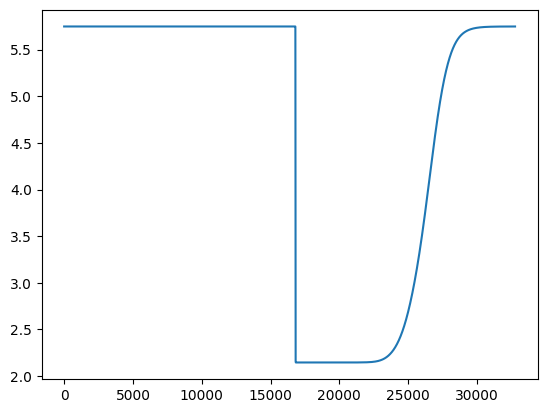

In [98]:
# Define silicon detector IDs
silicon_detectors = [2, 5]

# Load TES traces for events in silicon detectors
events = []
for det in silicon_detectors:
    events += index[det]

if DEBUG: print(len(set(events)) == len(events))    # See if EventNums across detectors are unique

# Preserves repeated EventNum entries (same event in multiple detectors)
data = get_traces_for_events(str(file_path), events, silicon_detectors)   # CDataFrame takes a string path
# data is a dict of NumPy arrays, aligned by index: {"Trace": [...], "ChanNum": [...], ...}

# Sanity check one trace
traces = data["Trace"]
plt.plot(traces[0])
plt.show()


In [99]:
# Combine traces from all silicon detectors into a single event list
# Flatten the dictionary values into a list of trace data dicts, each item in the list corresponds to a detector-event
all_event_bundles = []

df_dict = {}
for key, value in data.items():
    # Ensure every trace in Trace is treated as an array object 
    # It will be entered as one object in the dataframe's Trace column
    df_dict[key] = list(value) if key == "Trace" else value

temp_df = pd.DataFrame(df_dict)
if DEBUG: print(temp_df.head(24))

# Group by EventNum (within this detector) and aggregate into lists
event_groups = temp_df.groupby(['EventNum', 'DetNum']).agg(list).reset_index()

# Convert to list of dicts and add to our master list
# Each element in the list corresponds to one row in the original DataFrame
all_event_bundles.extend(event_groups.to_dict('records'))

# Check how many detector-events were found
num_si_events = len(all_event_bundles)
print(f"Number of Detector-Events found: {num_si_events}")

# Visually inspect first event dict in the event list
if DEBUG: print(*(f"{k}: {v}\n" for k, v in all_event_bundles[0].items()), sep="")

# Validation: verify each event has 12 traces, warn if any are found otherwise
for event in all_event_bundles:
    if len(event['Trace']) != 12:
        print(f"WARNING: Event {event['EventNum']} has {len(event['Trace'])} traces.")

    EventNum  DetNum  ChanNum ChanName  \
0        2.0     2.0      0.0     PFS1   
1        2.0     2.0      1.0     PCS1   
2        2.0     2.0      2.0     PDS1   
3        2.0     2.0      3.0     PBS1   
4        2.0     2.0      4.0     PES1   
5        2.0     2.0      5.0     PAS1   
6        2.0     2.0      6.0     PFS2   
7        2.0     2.0      7.0     PCS2   
8        2.0     2.0      8.0     PBS2   
9        2.0     2.0      9.0     PES2   
10       2.0     2.0     10.0     PDS2   
11       2.0     2.0     11.0     PAS2   
12       7.0     5.0      0.0     PFS1   
13       7.0     5.0      1.0     PCS1   
14       7.0     5.0      2.0     PDS1   
15       7.0     5.0      3.0     PBS1   
16       7.0     5.0      4.0     PES1   
17       7.0     5.0      5.0     PAS1   
18       7.0     5.0      6.0     PFS2   
19       7.0     5.0      7.0     PCS2   
20       7.0     5.0      8.0     PBS2   
21       7.0     5.0      9.0     PES2   
22       7.0     5.0     10.0     

## Get total event energy proxies

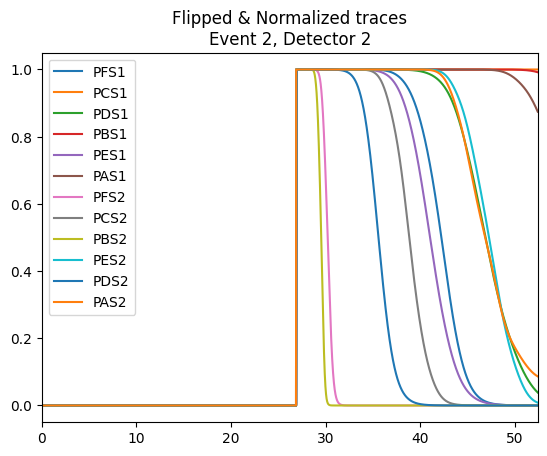

In [100]:
# Integrate over traces to get a total energy proxy and examine the energy distribution

# Show first trace after flip and normalization
show_trace = True

for evt in all_event_bundles:
    # Dont mutate input events
    traces = [t.copy() for t in evt["Trace"]]

    eventNum = int(evt["EventNum"])
    detNum = int(evt["DetNum"])
    channels = evt["ChanName"]
    bins = evt["BinWidth"]

    # Ensure bins are all the same and assign this as dt
    bins_unique = list(np.unique(bins))
    if len(bins_unique) > 1:
        print(f"Warning: Varying bin sizes found for event traces {eventNum} in detector {detNum}")
        break
    dt = bins[0]

    # Flip traces and normalize 
    # Note, normalize is done by (trace - min_val) / (max_val - min_val)
    traces = flip_traces(traces)
    traces = normalize_traces(traces)

    # Sanity check modified traces for first event
    if show_trace:
        show_trace = False      # Show only on first loop
        for i, trace in enumerate(traces):
            t, y = get_trace_t_y(
                trace,
                dt=dt
            )
            plt.plot(t, y, label=channels[i])
        plt.title(f"Flipped & Normalized traces\nEvent {eventNum}, Detector {detNum}")
        plt.xlim(t.min(), t.max())
        plt.legend()
        plt.show()

    # Add modified traces to event data
    evt["FlipNormTrace"] = traces

    # For each event, integrate all 12 traces and sum them 
    # This is a proxy for the total energy deposited in the detector for that event
    evt["TotalEnergyProxy"] = sum(
        np.trapezoid(trace, dx=dt) 
        for trace in traces
    )

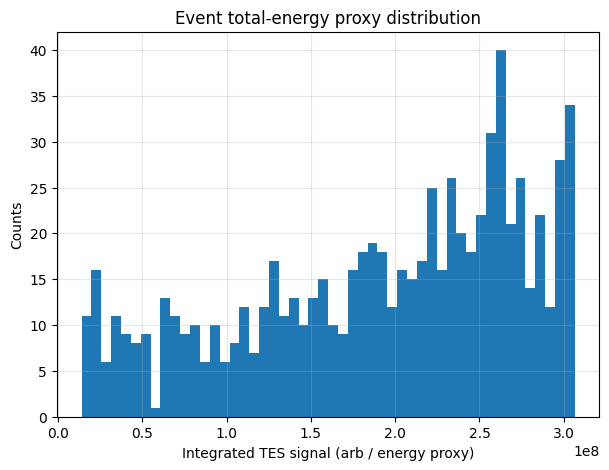

In [101]:
# Plot histogram energy distribution
energies = [evt["TotalEnergyProxy"] for evt in all_event_bundles]

plt.figure(figsize=(7,5))
plt.hist(energies, bins=50)
plt.xlabel("Integrated TES signal (arb / energy proxy)")
plt.ylabel("Counts")
plt.title("Event total-energy proxy distribution")
plt.grid(alpha=0.3)

plt.show()

## Determine saturation point

In [102]:
# Method for determining if a trace is saturated

# Get percentage of bins that have full saturation (==1) for normalized traces
# The number of bins that are maxxed will vary per event
# Count number of maxxed bins for each event and add this metric to its data dict
for evt in all_event_bundles:
    # Trim off preceding flat line of traces
    traces_matrix = np.array(evt["FlipNormTrace"])
    
    # Check which indices across ALL traces are > 0.01 (small value close to 0)
    # np.any(..., axis=0) tells us: "Is any detector active at this time step?"
    active_mask = np.any(traces_matrix > 0.01, axis=0)
    
    # Find the very first index where the mask is True
    indices = np.where(active_mask)[0]

    if indices.size > 0:
        first_nonzero_idx = indices[0]
        # Slice the 2D matrix along the columns (time axis)
        # Result is (12, remaining_samples)
        result = traces_matrix[:, first_nonzero_idx:]
    else:
        # If no trace ever goes above 0, return an empty 2D array
        result = np.empty((traces_matrix.shape[0], 0))
    
    evt["TrimmedTrace"] = result

    # Convert list of 12 traces into a 2D NumPy array (12, samples)
    traces_matrix = np.array(evt["TrimmedTrace"])
    
    # Use small tolerance or >= to catch saturated values
    # This creates a boolean mask of the same shape as traces_matrix
    is_saturated = traces_matrix >= 0.999 
    
    # Sum all True values across the entire event
    max_value_counts = np.sum(is_saturated)
    
    # Calculate fraction
    # Total possible points = (Number of traces) * (Samples per trace)
    total_possible_points = traces_matrix.size 
    
    evt["MaxValCounts"] = max_value_counts
    evt["FractionMax"] = max_value_counts / total_possible_points
# End for-loop

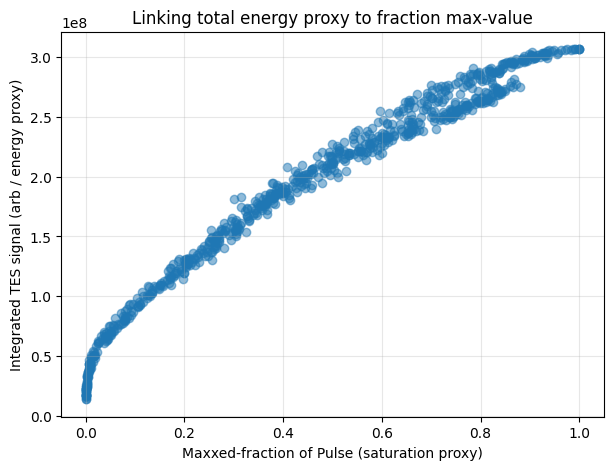

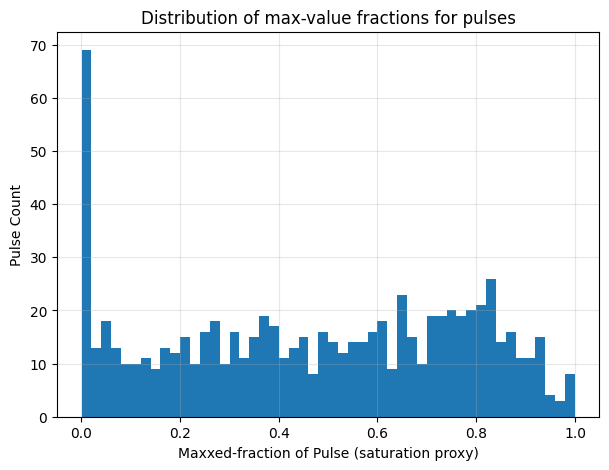

In [103]:
# Plot energy proxy versus fraction saturated
energies    = [evt["TotalEnergyProxy"] for evt in all_event_bundles]
fractionSat = [evt["FractionMax"] for evt in all_event_bundles]

plt.figure(figsize=(7,5))
plt.scatter(fractionSat, energies, alpha=0.5)
plt.xlabel("Maxxed-fraction of Pulse (saturation proxy)")
plt.ylabel("Integrated TES signal (arb / energy proxy)")
plt.title("Linking total energy proxy to fraction max-value")
plt.grid(alpha=0.3)

plt.show()

# Plot histogram of maxValue-fraction
plt.figure(figsize=(7,5))
plt.hist(fractionSat, bins=50)
plt.xlabel("Maxxed-fraction of Pulse (saturation proxy)")
plt.ylabel("Pulse Count")
plt.title("Distribution of max-value fractions for pulses")
plt.grid(alpha=0.3)

plt.show()

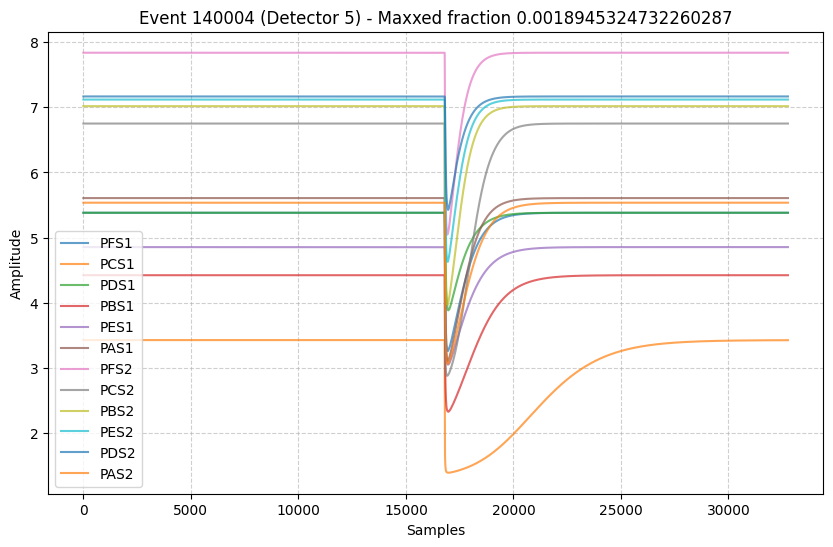

In [104]:
# Plot an event that occurs at at certain saturation
# Find the first event that meets the criteria
# next() takes a generator and an optional default value (None) if no match is found
range_l = 0.0018
range_h = 0.002
target_event = next((evt for evt in all_event_bundles if range_l <= evt["FractionMax"] <= range_h), None)

if target_event is not None:
    traces      = target_event["Trace"]
    event_id    = int(target_event["EventNum"])
    det_id      = int(target_event["DetNum"])
    channels    = target_event["ChanName"]
    saturation  = target_event["FractionMax"]
    
    plt.figure(figsize=(10, 6))
    
    # Plot each of the 12 traces
    # Since traces is a 2D numpy array, iterating over it yields each row
    for i, trace in enumerate(traces):
        plt.plot(trace, label=f"{channels[i]}", alpha=0.7)
    
    plt.title(f"Event {event_id} (Detector {det_id}) - Maxxed fraction {saturation}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

else:
    print(f"No events found with a max-value fraction within selected range [{range_l}, {range_h}]")

## Link energy proxy to actual Edep

In [105]:
# Load g4dmcHits
# Filter trueEnergy by events that occurred in silicon detectors
cut = build_cut_string(events, silicon_detectors)
hitsData = CDataFrame('G4SimDir/g4dmcHits', str(file_path)).Filter(cut)
hitsDict = {
    "trueEnergy": hitsData.AsNumpy(['trueEnergy'])['trueEnergy'],
    "EventNum": hitsData.AsNumpy(['EventNum'])['EventNum'],
    "DetNum": hitsData.AsNumpy(['DetNum'])['DetNum'],
}

# Convert hits to a DataFrame
df_hits = pd.DataFrame(hitsDict)
if DEBUG: print(df_hits.head)

# Sum trueEnergy grouped by Event and Detector 
# ************************************************************
# NOTE: This combines energies of hits in the same detector that occured from the same event 
# However, it is not determined here whether these htis were truly combined to give one unique TESSim event
# ************************************************************

# (In case one event has multiple hit entries in the simulation)
df_hits_grouped = df_hits.groupby(['EventNum', 'DetNum'])['trueEnergy'].sum().reset_index()
if DEBUG: print(df_hits_grouped.head)

# Merge into all_event_bundles
df_bundles = pd.DataFrame(all_event_bundles)

# Merge the energy data in
df_combined = pd.merge(
    df_bundles, 
    df_hits_grouped, 
    on=['EventNum', 'DetNum'], 
    how='left'
)

# Convert back to detctor-event list
all_event_bundles = df_combined.to_dict('records')
if DEBUG: print(*(f"{k}: {v}\n" for k, v in all_event_bundles[0].items()), sep="")


<bound method NDFrame.head of          trueEnergy  EventNum  DetNum
0      56326.091196       2.0     2.0
1      11220.888743       2.0     2.0
2     100057.192979       7.0     5.0
3     153847.207920      15.0     2.0
4      91000.418169      17.0     5.0
...             ...       ...     ...
1013   84048.285279  990015.0     5.0
1014   62299.061957  990020.0     2.0
1015   45211.479333  990026.0     5.0
1016   63058.259528  990027.0     5.0
1017  149038.856670  990027.0     5.0

[1018 rows x 3 columns]>
<bound method NDFrame.head of      EventNum  DetNum     trueEnergy
0         2.0     2.0   67546.979939
1         7.0     5.0  100057.192979
2        15.0     2.0  153847.207920
3        17.0     5.0   91000.418169
4        19.0     2.0  133336.816048
..        ...     ...            ...
754  990011.0     5.0   32530.888723
755  990015.0     5.0  104604.180037
756  990020.0     2.0   62299.061957
757  990026.0     5.0   45211.479333
758  990027.0     5.0  212097.116198

[759 rows x 3

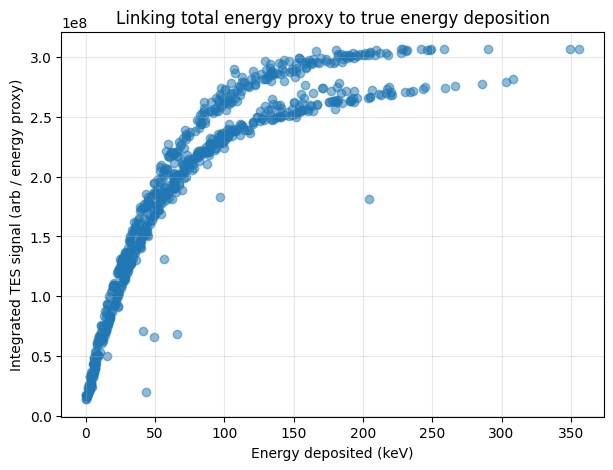

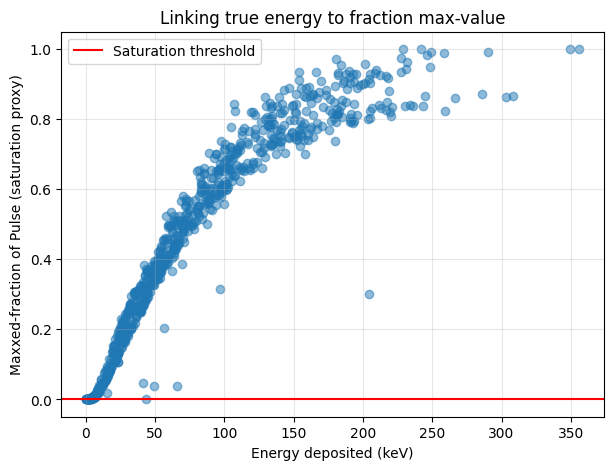

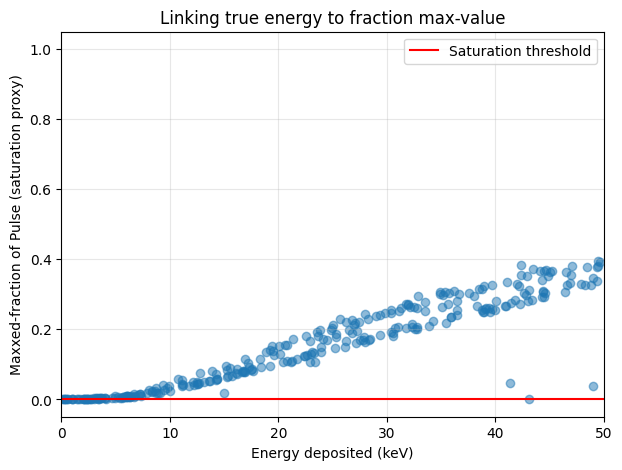

In [106]:
# Plot energy proxy versus actual energy deposited
energyProxies   = [evt["TotalEnergyProxy"] for evt in all_event_bundles]
energiesTrue    = [evt["trueEnergy"]*1e-3 for evt in all_event_bundles]     # eV to keV
fractionSat = [evt["FractionMax"] for evt in all_event_bundles]

plt.figure(figsize=(7,5))
plt.scatter(energiesTrue, energyProxies, alpha=0.5)
plt.xlabel("Energy deposited (keV)")
plt.ylabel("Integrated TES signal (arb / energy proxy)")
plt.title("Linking total energy proxy to true energy deposition")
plt.grid(alpha=0.3)

plt.show()

# Plot fraction saturated versus actual energy deposited
saturation_threshold = 0.002

plt.figure(figsize=(7,5))
plt.scatter(energiesTrue, fractionSat, alpha=0.5)
plt.axhline(y=saturation_threshold, label="Saturation threshold", color='r')
plt.xlabel("Energy deposited (keV)")
plt.ylabel("Maxxed-fraction of Pulse (saturation proxy)")
plt.title("Linking true energy to fraction max-value")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Zoom in on this plot
plt.figure(figsize=(7,5))
plt.scatter(energiesTrue, fractionSat, alpha=0.5)
plt.axhline(y=saturation_threshold, label="Saturation threshold", color='r')

# Zoom
plt.xlim(0, 50)

plt.xlabel("Energy deposited (keV)")
plt.ylabel("Maxxed-fraction of Pulse (saturation proxy)")
plt.title("Linking true energy to fraction max-value")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [107]:
# Create a boolean mask for the condition
if DEBUG: print(df_combined.columns)

mask = df_combined['FractionMax'] < saturation_threshold
sorted_low_sat = df_combined[mask].sort_values(by='trueEnergy', ascending=False)

# Count the rows matching the mask
num_low_sat = mask.sum()

# View the top 5 to see the outlier vs the pack
print(sorted_low_sat[['EventNum', 'trueEnergy', 'FractionMax']].head(5))

# Print stats
print(f"Events with {saturation_threshold} max-values: {num_low_sat}, {(num_low_sat * 100 / num_si_events):.2f}% of Si events")

Index(['EventNum', 'DetNum', 'ChanNum', 'ChanName', 'Trace', 'T0', 'BinWidth',
       'FlipNormTrace', 'TotalEnergyProxy', 'TrimmedTrace', 'MaxValCounts',
       'FractionMax', 'trueEnergy'],
      dtype='object')
     EventNum    trueEnergy  FractionMax
334  460016.0  43136.748748     0.000590
512  670012.0   2992.708672     0.001968
194  290021.0   2733.746444     0.001493
281  400014.0   2711.376768     0.001654
92   130012.0   2539.078094     0.001440
Events with 0.002 max-values: 26, 3.43% of Si events


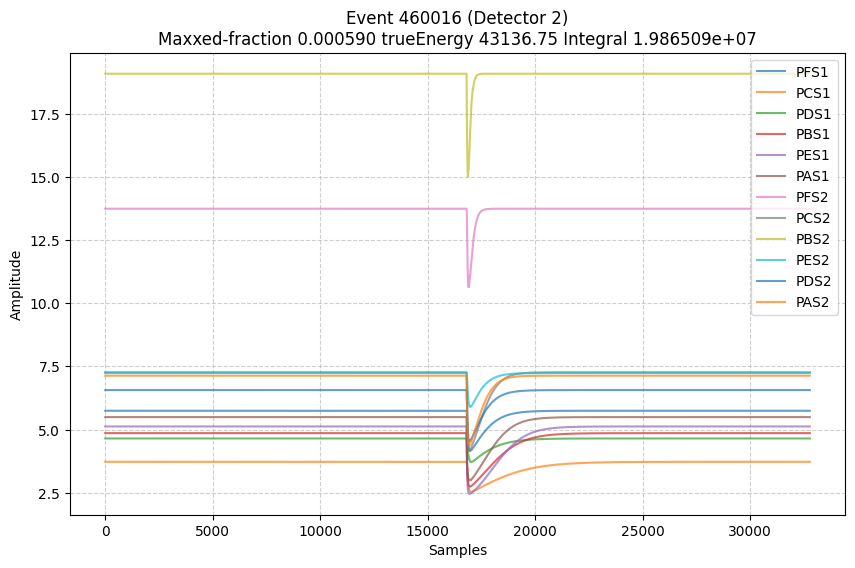

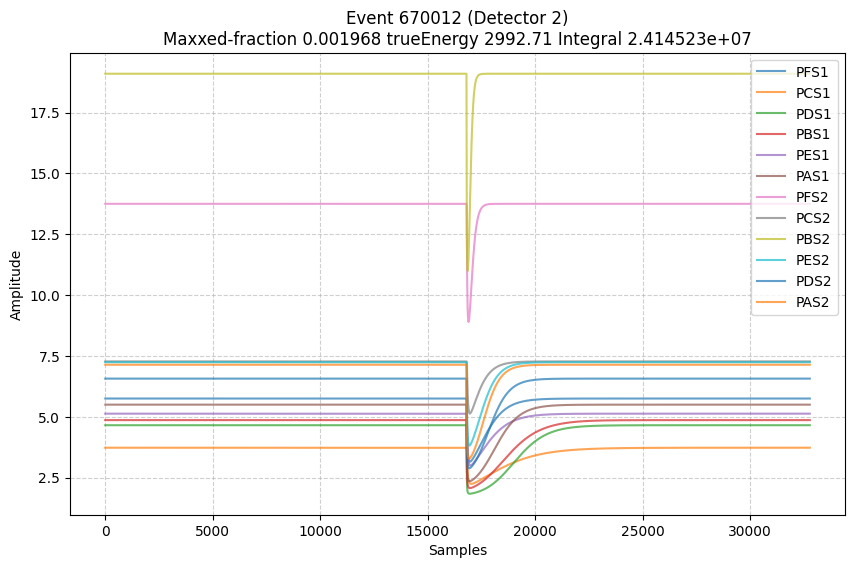

In [117]:
# Plot the outlier 43 keV event to examine its saturation

event43kev = df_combined.iloc[334]
event3kev = df_combined.iloc[512] 

def plot_traces(event_row):
    traces      = event_row["Trace"]
    event_id    = int(event_row["EventNum"])
    det_id      = int(event_row["DetNum"])
    channels    = event_row["ChanName"]
    saturation  = event_row["FractionMax"]
    energy      = event_row["trueEnergy"]
    energyProxy = event_row["TotalEnergyProxy"]

    plt.figure(figsize=(10, 6))

    # Plot each of the 12 traces
    # Since traces is a 2D numpy array, iterating over it yields each row
    for i, trace in enumerate(traces):
        plt.plot(trace, label=f"{channels[i]}", alpha=0.7)

    plt.title(f"Event {event_id} (Detector {det_id})\n"
              f"Maxxed-fraction {saturation:.6f} trueEnergy {energy:.2f} Integral {energyProxy:e}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

plot_traces(event43kev)
plot_traces(event3kev)
